In [1]:
! pip install numpy opencv-python matplotlib

In [2]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

In [3]:
# img = cv2.imread('images/swan_copy.png')
# img_orig = cv2.imread('images/swan.png')

In [4]:
img = cv2.imread('images/tree_copy.png')
img_orig = cv2.imread('images/tree.png')

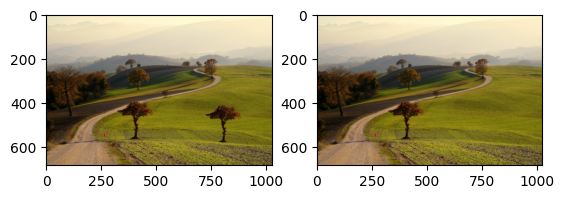

In [5]:
plt.subplot(121)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.subplot(122)
plt.imshow(cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB))

In [6]:
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img = cv2.resize(img, (0,0), fx=0.8, fy=0.8)

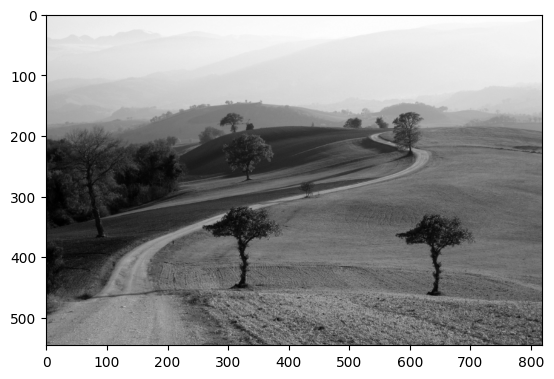

In [7]:
plt.imshow(img, cmap='gray')

In [8]:
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
img = clahe.apply(img)

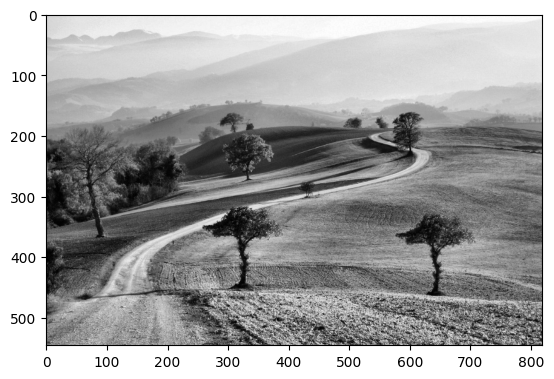

In [9]:
plt.imshow(img, cmap='gray')

detect and describe with ORB

In [10]:
orb = cv2.ORB_create(nfeatures=5000)
kps, desc = orb.detectAndCompute(img, None)

In [11]:
len(kps), desc.shape

(4746, (4746, 32))

match descriptors with BFMatcher (Hamming for ORB)

In [12]:
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)
matches = bf.knnMatch(desc, desc, k=3)

Lowe ratio test and remove self-matches (same keypoint)

In [13]:
good = []
for knn in matches:
    # find first neighbor that is not itself
    m = next((c for c in knn if c.queryIdx != c.trainIdx), None)
    if m is None:
        continue

    # next best for ratio test
    n = next((c for c in knn if c.queryIdx != c.trainIdx and c.trainIdx != m.trainIdx), None)
    if n is None:
        continue

    # ratio test
    if m.distance < 0.75 * n.distance:
        # optional: spatial distance check
        p = np.array(kps[m.queryIdx].pt)
        q = np.array(kps[m.trainIdx].pt)
        if np.linalg.norm(p - q) > 5:
            good.append((m.queryIdx, m.trainIdx))

In [14]:
len(good)

144

In [15]:
pts1 = np.float32([kps[i].pt for i, _ in good])
pts2 = np.float32([kps[j].pt for _, j in good])

geometric verification with RANSAC (estimate affine or homography)

In [16]:
M, mask = cv2.estimateAffine2D(pts1, pts2, method=cv2.RANSAC, ransacReprojThreshold=5.0)
# mask is 1 for inliers
inliers = [good[idx] for idx, mval in enumerate(mask.ravel()) if mval == 1]

In [17]:
len(inliers)

46

create mask from inlier keypoints pairs: paint circles at the matched locations

In [18]:
mask_img = np.zeros(img.shape, dtype=np.uint8)
for i, j in inliers:
    p = tuple(map(int, kps[i].pt))
    q = tuple(map(int, kps[j].pt))
    cv2.circle(mask_img, p, 12, 255, -1)
    cv2.circle(mask_img, q, 12, 255, -1)

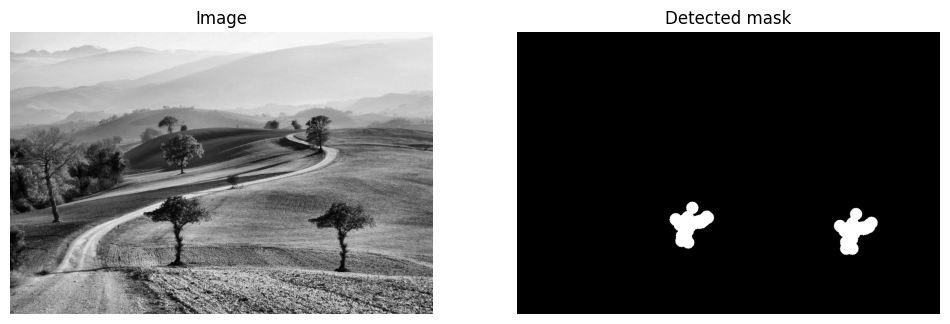

In [19]:
fig, ax = plt.subplots(1,2, figsize=(12,6))
ax[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); ax[0].set_title('Image'); ax[0].axis('off')
ax[1].imshow(mask_img, cmap='gray'); ax[1].set_title('Detected mask'); ax[1].axis('off')
plt.show()